# Wav2Vec 2.0 Speech Classification — 16-bit then 1-bit, cell by cell

Structure of this notebook:
1. **Shared setup** (imports, seeding, config, model/utility definitions) — run once.
2. **PART A — 16-bit condition**, fully self-contained, one cell per stage.
3. **PART B — 1-bit condition**, same structure, same stage schedule, separate variables.
4. **Final comparison** between the two conditions.

Same bug fixes as before apply throughout: proper input normalization matching the
pretrained checkpoint, seeded reproducibility, a layer-weighted pooling head instead
of last-layer-only mean pooling, a leakage check, an MFCC baseline, and a bootstrap
CI + McNemar test at the end. I have not run this myself (no GPU / no dataset here),
so no output numbers below are real — run it and report whatever you actually get.


In [2]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/y_train.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/y_test.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/y_val.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/X_test.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/X_val.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit/X_train.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/y_1bit_test.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/X_1bit_test.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/y_1bit_val.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/y_1bit_train.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/X_1bit_val.npy
/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit/X_1bit_train.npy


In [3]:
# ============================================================
# Shared Setup — 0. Environment
# ============================================================
!pip install -q transformers==4.44.2 accelerate scikit-learn scipy librosa


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 64.5 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 81.9 MB/s eta 0:00:00:00:01


In [4]:
# ============================================================
# Shared Setup — 1. Imports & Reproducibility
# ============================================================
import os
import gc
import copy
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor, get_cosine_schedule_with_warmup

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
)
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from scipy.stats import chi2
import librosa


def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


SEED = 42
seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [5]:
# ============================================================
# Shared Setup — 2. Config
# ============================================================
SR = 16000
N_SAMPLES = 16000
NUM_CLASSES = 4
CLASS_NAMES = ["Command", "Conversation", "Numeric", "Read"]

PRETRAINED_CKPT = "facebook/wav2vec2-base"

BATCH_SIZE = 8
NUM_WORKERS = 2

# Stage schedule used IDENTICALLY for both 16-bit and 1-bit, so any difference in
# results reflects the data, not an inconsistency in the training recipe (this was
# a bug in the original notebook: 16-bit unfroze 4 layers once; 1-bit unfroze 4
# then 8 layers across three separate stages with different epoch counts).
STAGES = [
    # (n_unfrozen_top_layers, max_epochs, lr, patience)
    (0, 8, 1e-4, 3),
    (4, 10, 1e-5, 4),
    (8, 8, 5e-6, 4),
]

WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0
WARMUP_RATIO = 0.1
LABEL_SMOOTHING = 0.05
USE_AMP = True

DATA16_DIR = "/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_16bit"
DATA1_DIR = "/kaggle/input/datasets/ramsudeep/preprocessed/preprocessed_1bit"

OUT_DIR = "/kaggle/working/results"
os.makedirs(OUT_DIR, exist_ok=True)

feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(PRETRAINED_CKPT)
print("Feature extractor do_normalize:", feature_extractor.do_normalize)


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

Feature extractor do_normalize: True


In [6]:
# ============================================================
# Shared Setup — 3. Dataset / leakage-check / describe utilities
# ============================================================
def load_split(data_dir, x_name, y_name):
    X = np.load(os.path.join(data_dir, x_name))
    y = np.load(os.path.join(data_dir, y_name))
    return X, y


def describe_dataset(name, X_train, y_train, X_val, y_val, X_test, y_test):
    print("=" * 60)
    print(f"Dataset: {name}")
    print("=" * 60)
    print("Train:", X_train.shape, y_train.shape)
    print("Val  :", X_val.shape, y_val.shape)
    print("Test :", X_test.shape, y_test.shape)
    print("dtype:", X_train.dtype, "| min:", X_train.min(), "| max:", X_train.max())
    for split_name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
        u, c = np.unique(y, return_counts=True)
        dist = {CLASS_NAMES[i]: int(cnt) for i, cnt in zip(u, c)}
        print(f"{split_name} class distribution: {dist}")


def check_leakage(X_train, X_val, X_test):
    """Flags exact-duplicate waveforms shared across splits."""
    def to_hashes(X):
        Xf = np.squeeze(X).astype(np.float32)
        return set(hash(Xf[i].tobytes()) for i in range(len(Xf)))

    h_train, h_val, h_test = to_hashes(X_train), to_hashes(X_val), to_hashes(X_test)
    lv = h_train & h_val
    lt = h_train & h_test
    vt = h_val & h_test
    print(f"Duplicate waveforms train∩val : {len(lv)}")
    print(f"Duplicate waveforms train∩test: {len(lt)}")
    print(f"Duplicate waveforms val∩test  : {len(vt)}")
    if lv or lt or vt:
        warnings.warn("Data leakage detected — fix the split before trusting test metrics.")
    return lv, lt, vt


class SpeechDataset(Dataset):
    """Applies the SAME normalization the pretrained checkpoint's feature
    extractor expects — this was silently skipped in the original notebook."""

    def __init__(self, X, y, feature_extractor, augment: bool = False):
        X = np.squeeze(X, axis=-1) if X.ndim == 3 else X
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)
        self.fe = feature_extractor
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def _normalize(self, wav):
        if self.fe.do_normalize:
            wav = (wav - wav.mean()) / (wav.std() + 1e-7)
        return wav

    def _augment(self, wav):
        if random.random() < 0.5:
            wav = wav * random.uniform(0.85, 1.15)
        if random.random() < 0.3:
            wav = wav + np.random.normal(0, 0.003, size=wav.shape).astype(np.float32)
        return wav

    def __getitem__(self, idx):
        wav = self.X[idx].copy()
        if self.augment:
            wav = self._augment(wav)
        wav = self._normalize(wav)
        return torch.tensor(wav, dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)


def make_loaders(X_train, y_train, X_val, y_val, X_test, y_test):
    train_ds = SpeechDataset(X_train, y_train, feature_extractor, augment=True)
    val_ds = SpeechDataset(X_val, y_val, feature_extractor, augment=False)
    test_ds = SpeechDataset(X_test, y_test, feature_extractor, augment=False)

    class_counts = np.bincount(y_train.astype(int), minlength=NUM_CLASSES)
    class_weights = 1.0 / np.maximum(class_counts, 1)
    sample_weights = class_weights[y_train.astype(int)]
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                               num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)
    return train_loader, val_loader, test_loader


In [7]:
# ============================================================
# Shared Setup — 4. Model definition
# ============================================================
class Wav2Vec2Classifier(nn.Module):
    """Backbone: pretrained Wav2Vec2Model (CNN feature encoder + Transformer
    context network) with `output_hidden_states=True`.

    Head: learned softmax-weighted sum across all Transformer layers (not just the
    last one), then attentive-mean + max pooling over time, then a small MLP.
    """

    def __init__(self, pretrained_ckpt: str, num_classes: int, dropout: float = 0.2):
        super().__init__()
        self.wav2vec2 = Wav2Vec2Model.from_pretrained(pretrained_ckpt)
        n_layers = self.wav2vec2.config.num_hidden_layers + 1
        hidden = self.wav2vec2.config.hidden_size

        self.layer_weights = nn.Parameter(torch.zeros(n_layers))
        self.attn_pool = nn.Linear(hidden, 1)
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )

    def freeze_all(self):
        for p in self.wav2vec2.parameters():
            p.requires_grad = False

    def unfreeze_top_layers(self, n: int):
        """Freeze everything, then unfreeze only the top-`n` Transformer layers
        (the CNN feature encoder stays frozen, matching the paper's own fine-tuning
        recipe)."""
        self.freeze_all()
        if n > 0:
            for layer in self.wav2vec2.encoder.layers[-n:]:
                for p in layer.parameters():
                    p.requires_grad = True
        for p in self.classifier.parameters():
            p.requires_grad = True
        for p in [self.layer_weights, self.attn_pool.weight, self.attn_pool.bias]:
            p.requires_grad = True

    def forward(self, input_values, attention_mask=None):
        out = self.wav2vec2(input_values=input_values, attention_mask=attention_mask,
                             output_hidden_states=True)
        hidden_states = torch.stack(out.hidden_states, dim=0)        # (L, B, T, H)
        weights = torch.softmax(self.layer_weights, dim=0).view(-1, 1, 1, 1)
        pooled_layers = (hidden_states * weights).sum(dim=0)         # (B, T, H)

        attn_scores = self.attn_pool(pooled_layers).squeeze(-1)
        attn_weights = torch.softmax(attn_scores, dim=-1).unsqueeze(-1)
        attn_vec = (pooled_layers * attn_weights).sum(dim=1)
        max_vec, _ = pooled_layers.max(dim=1)

        feat = torch.cat([attn_vec, max_vec], dim=-1)
        return self.classifier(feat)

    def trainable_param_summary(self):
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        return trainable, total


In [8]:
# ============================================================
# Shared Setup — 5. Train / eval / reporting utilities
# ============================================================
def train_one_epoch(model, loader, optimizer, criterion, scheduler=None):
    model.train()
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    running_loss, correct, total = 0.0, 0, 0

    for waveforms, labels in loader:
        waveforms, labels = waveforms.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(input_values=waveforms)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(filter(lambda p: p.requires_grad, model.parameters()), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        if scheduler is not None:
            scheduler.step()

        running_loss += loss.item()
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return running_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, return_predictions=False):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_probs, all_labels = [], [], []

    for waveforms, labels in loader:
        waveforms, labels = waveforms.to(device), labels.to(device)
        logits = model(input_values=waveforms)
        loss = criterion(logits, labels)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        running_loss += loss.item()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if return_predictions:
            all_preds.append(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    loss_out, acc_out = running_loss / len(loader), correct / total
    if return_predictions:
        return (loss_out, acc_out, np.concatenate(all_preds),
                np.concatenate(all_probs), np.concatenate(all_labels))
    return loss_out, acc_out


def full_test_report(model, test_loader, tag: str):
    criterion = nn.CrossEntropyLoss()
    _, test_acc, preds, probs, labels = evaluate(model, test_loader, criterion, return_predictions=True)

    precision = precision_score(labels, preds, average="macro", zero_division=0)
    recall = recall_score(labels, preds, average="macro", zero_division=0)
    f1 = f1_score(labels, preds, average="macro", zero_division=0)

    labels_bin = label_binarize(labels, classes=list(range(NUM_CLASSES)))
    try:
        roc_auc = roc_auc_score(labels_bin, probs, average="macro", multi_class="ovr")
    except ValueError:
        roc_auc = float("nan")

    eers = []
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
        try:
            eer = brentq(lambda x: 1.0 - x - interp1d(fpr, tpr)(x), 0.0, 1.0)
        except ValueError:
            eer = float("nan")
        eers.append(eer)
    eer = float(np.nanmean(eers))

    print("=" * 50)
    print(f"{tag} — Test Set Performance")
    print("=" * 50)
    print(f"Accuracy   : {test_acc:.4f}")
    print(f"Precision  : {precision:.4f}")
    print(f"Recall     : {recall:.4f}")
    print(f"F1 (macro) : {f1:.4f}")
    print(f"ROC-AUC    : {roc_auc:.4f}")
    print(f"EER        : {eer:.4f}\n")
    print(classification_report(labels, preds, target_names=CLASS_NAMES, digits=4))

    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(6, 6))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title(f"Confusion Matrix — {tag}")
    plt.tight_layout()
    plt.show()

    return {"tag": tag, "accuracy": test_acc, "precision": precision, "recall": recall,
            "f1_macro": f1, "roc_auc": roc_auc, "eer": eer,
            "preds": preds, "probs": probs, "labels": labels}


def extract_mfcc_features(X, sr=SR, n_mfcc=20):
    X = np.squeeze(X)
    feats = []
    for i in range(len(X)):
        mfcc = librosa.feature.mfcc(y=X[i].astype(np.float32), sr=sr, n_mfcc=n_mfcc)
        feats.append(np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)]))
    return np.array(feats)


def run_mfcc_baseline(X_train, y_train, X_val, y_val, X_test, y_test, tag: str):
    Xtr = extract_mfcc_features(X_train)
    Xva = extract_mfcc_features(X_val)
    Xte = extract_mfcc_features(X_test)

    scaler = StandardScaler().fit(np.concatenate([Xtr, Xva], axis=0))
    Xtr, Xva, Xte = scaler.transform(Xtr), scaler.transform(Xva), scaler.transform(Xte)

    clf = LogisticRegression(max_iter=2000, multi_class="multinomial")
    clf.fit(np.concatenate([Xtr, Xva]), np.concatenate([y_train, y_val]))

    preds = clf.predict(Xte)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")
    print(f"[{tag}] MFCC + LogisticRegression baseline — Test Acc: {acc:.4f} | Macro-F1: {f1:.4f}")
    return {"tag": tag, "accuracy": acc, "macro_f1": f1}


def plot_history(history_rows, tag: str):
    h = pd.DataFrame(history_rows)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(h["global_epoch"], h["train_acc"], label="train")
    axes[0].plot(h["global_epoch"], h["val_acc"], label="val")
    axes[0].set_title(f"{tag} — Accuracy"); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(h["global_epoch"], h["train_loss"], label="train")
    axes[1].plot(h["global_epoch"], h["val_loss"], label="val")
    axes[1].set_title(f"{tag} — Loss"); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    return h


---
# PART A — 16-bit condition
---

In [9]:
# ============================================================
# [16-bit] 1. Load data + sanity checks
# ============================================================
X_train_16, y_train_16 = load_split(DATA16_DIR, "X_train.npy", "y_train.npy")
X_val_16, y_val_16 = load_split(DATA16_DIR, "X_val.npy", "y_val.npy")
X_test_16, y_test_16 = load_split(DATA16_DIR, "X_test.npy", "y_test.npy")

describe_dataset("16-bit", X_train_16, y_train_16, X_val_16, y_val_16, X_test_16, y_test_16)
check_leakage(X_train_16, X_val_16, X_test_16)


Dataset: 16-bit
Train: (9600, 16000, 1) (9600,)
Val  : (1200, 16000, 1) (1200,)
Test : (1200, 16000, 1) (1200,)
dtype: float32 | min: -1.0 | max: 1.0
train class distribution: {'Command': 2400, 'Conversation': 2400, 'Numeric': 2400, 'Read': 2400}
val class distribution: {'Command': 300, 'Conversation': 300, 'Numeric': 300, 'Read': 300}
test class distribution: {'Command': 300, 'Conversation': 300, 'Numeric': 300, 'Read': 300}
Duplicate waveforms train∩val : 0
Duplicate waveforms train∩test: 0
Duplicate waveforms val∩test  : 0


(set(), set(), set())

In [10]:
# ============================================================
# [16-bit] 2. DataLoaders
# ============================================================
train_loader_16, val_loader_16, test_loader_16 = make_loaders(
    X_train_16, y_train_16, X_val_16, y_val_16, X_test_16, y_test_16
)

waveforms, labels = next(iter(train_loader_16))
print("Waveforms:", waveforms.shape, waveforms.dtype)
print("Labels   :", labels.shape, labels.dtype)


Waveforms: torch.Size([8, 16000]) torch.float32
Labels   : torch.Size([8]) torch.int64


In [11]:
# ============================================================
# [16-bit] 3. Model
# ============================================================
seed_everything(SEED)
model_16bit = Wav2Vec2Classifier(PRETRAINED_CKPT, NUM_CLASSES).to(device)
criterion_16bit = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

best_val_acc_16 = 0.0
best_state_16 = None
history_16 = []
global_epoch_16 = 0


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [12]:
# ============================================================
# [16-bit] 4. Stage 1 — classifier head only
# ============================================================
stage = 1
n_unfrozen, max_epochs, lr, patience = STAGES[stage - 1]

model_16bit.unfreeze_top_layers(n_unfrozen)
trainable, total = model_16bit.trainable_param_summary()
print(f"[16-bit] Stage {stage}: unfreeze last {n_unfrozen} layers | trainable {trainable:,} / {total:,}")

optimizer_16bit = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_16bit.parameters()), lr=lr, weight_decay=WEIGHT_DECAY
)
n_steps = max_epochs * len(train_loader_16)
scheduler_16bit = get_cosine_schedule_with_warmup(
    optimizer_16bit, num_warmup_steps=int(WARMUP_RATIO * n_steps), num_training_steps=n_steps
)

patience_counter = 0
for epoch in range(max_epochs):
    tr_loss, tr_acc = train_one_epoch(model_16bit, train_loader_16, optimizer_16bit, criterion_16bit, scheduler_16bit)
    va_loss, va_acc = evaluate(model_16bit, val_loader_16, criterion_16bit)
    global_epoch_16 += 1

    print(f"[16-bit] Stage {stage} Epoch {epoch+1}/{max_epochs} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {va_loss:.4f} Acc {va_acc:.4f}")
    history_16.append({"global_epoch": global_epoch_16, "stage": stage,
                        "train_loss": tr_loss, "train_acc": tr_acc, "val_loss": va_loss, "val_acc": va_acc})

    if va_acc > best_val_acc_16:
        best_val_acc_16 = va_acc
        best_state_16 = copy.deepcopy(model_16bit.state_dict())
        torch.save(best_state_16, os.path.join(OUT_DIR, "best_wav2vec2_16bit.pth"))
        patience_counter = 0
        print(f"  -> new best (Val Acc = {best_val_acc_16:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("  -> early stopping stage", stage)
            break

print(f"\n[16-bit] Stage 1 finished. Best Val Acc so far: {best_val_acc_16:.4f}")


[16-bit] Stage 1: unfreeze last 0 layers | trainable 1,184,274 / 95,555,986
[16-bit] Stage 1 Epoch 1/8 | Train Loss 0.9276 Acc 0.6752 | Val Loss 0.5226 Acc 0.8867
  -> new best (Val Acc = 0.8867)
[16-bit] Stage 1 Epoch 2/8 | Train Loss 0.4490 Acc 0.9044 | Val Loss 0.3643 Acc 0.9458
  -> new best (Val Acc = 0.9458)
[16-bit] Stage 1 Epoch 3/8 | Train Loss 0.3781 Acc 0.9365 | Val Loss 0.3385 Acc 0.9583
  -> new best (Val Acc = 0.9583)
[16-bit] Stage 1 Epoch 4/8 | Train Loss 0.3569 Acc 0.9424 | Val Loss 0.3318 Acc 0.9667
  -> new best (Val Acc = 0.9667)
[16-bit] Stage 1 Epoch 5/8 | Train Loss 0.3444 Acc 0.9511 | Val Loss 0.3192 Acc 0.9683
  -> new best (Val Acc = 0.9683)
[16-bit] Stage 1 Epoch 6/8 | Train Loss 0.3299 Acc 0.9593 | Val Loss 0.3127 Acc 0.9692
  -> new best (Val Acc = 0.9692)
[16-bit] Stage 1 Epoch 7/8 | Train Loss 0.3291 Acc 0.9590 | Val Loss 0.3141 Acc 0.9700
  -> new best (Val Acc = 0.9700)
[16-bit] Stage 1 Epoch 8/8 | Train Loss 0.3251 Acc 0.9598 | Val Loss 0.3136 Acc 0.96

In [13]:
# ============================================================
# [16-bit] 5. Stage 2 — unfreeze last 4 transformer layers
# ============================================================
stage = 2
n_unfrozen, max_epochs, lr, patience = STAGES[stage - 1]

model_16bit.load_state_dict(best_state_16)  # continue from best Stage-1 weights
model_16bit.unfreeze_top_layers(n_unfrozen)
trainable, total = model_16bit.trainable_param_summary()
print(f"[16-bit] Stage {stage}: unfreeze last {n_unfrozen} layers | trainable {trainable:,} / {total:,}")

optimizer_16bit = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_16bit.parameters()), lr=lr, weight_decay=WEIGHT_DECAY
)
n_steps = max_epochs * len(train_loader_16)
scheduler_16bit = get_cosine_schedule_with_warmup(
    optimizer_16bit, num_warmup_steps=int(WARMUP_RATIO * n_steps), num_training_steps=n_steps
)

patience_counter = 0
for epoch in range(max_epochs):
    tr_loss, tr_acc = train_one_epoch(model_16bit, train_loader_16, optimizer_16bit, criterion_16bit, scheduler_16bit)
    va_loss, va_acc = evaluate(model_16bit, val_loader_16, criterion_16bit)
    global_epoch_16 += 1

    print(f"[16-bit] Stage {stage} Epoch {epoch+1}/{max_epochs} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {va_loss:.4f} Acc {va_acc:.4f}")
    history_16.append({"global_epoch": global_epoch_16, "stage": stage,
                        "train_loss": tr_loss, "train_acc": tr_acc, "val_loss": va_loss, "val_acc": va_acc})

    if va_acc > best_val_acc_16:
        best_val_acc_16 = va_acc
        best_state_16 = copy.deepcopy(model_16bit.state_dict())
        torch.save(best_state_16, os.path.join(OUT_DIR, "best_wav2vec2_16bit.pth"))
        patience_counter = 0
        print(f"  -> new best (Val Acc = {best_val_acc_16:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("  -> early stopping stage", stage)
            break

print(f"\n[16-bit] Stage 2 finished. Best Val Acc so far: {best_val_acc_16:.4f}")


[16-bit] Stage 2: unfreeze last 4 layers | trainable 29,535,762 / 95,555,986
[16-bit] Stage 2 Epoch 1/10 | Train Loss 0.3268 Acc 0.9600 | Val Loss 0.3086 Acc 0.9717
  -> new best (Val Acc = 0.9717)
[16-bit] Stage 2 Epoch 2/10 | Train Loss 0.3126 Acc 0.9645 | Val Loss 0.3180 Acc 0.9683
[16-bit] Stage 2 Epoch 3/10 | Train Loss 0.2947 Acc 0.9722 | Val Loss 0.2820 Acc 0.9800
  -> new best (Val Acc = 0.9800)
[16-bit] Stage 2 Epoch 4/10 | Train Loss 0.2790 Acc 0.9800 | Val Loss 0.2698 Acc 0.9875
  -> new best (Val Acc = 0.9875)
[16-bit] Stage 2 Epoch 5/10 | Train Loss 0.2684 Acc 0.9832 | Val Loss 0.2651 Acc 0.9900
  -> new best (Val Acc = 0.9900)
[16-bit] Stage 2 Epoch 6/10 | Train Loss 0.2626 Acc 0.9856 | Val Loss 0.2650 Acc 0.9892
[16-bit] Stage 2 Epoch 7/10 | Train Loss 0.2526 Acc 0.9892 | Val Loss 0.2615 Acc 0.9892
[16-bit] Stage 2 Epoch 8/10 | Train Loss 0.2527 Acc 0.9871 | Val Loss 0.2579 Acc 0.9900
[16-bit] Stage 2 Epoch 9/10 | Train Loss 0.2495 Acc 0.9889 | Val Loss 0.2560 Acc 0.9917

In [14]:
# ============================================================
# [16-bit] 6. Stage 3 — unfreeze last 8 transformer layers
# ============================================================
stage = 3
n_unfrozen, max_epochs, lr, patience = STAGES[stage - 1]

model_16bit.load_state_dict(best_state_16)  # continue from best Stage-2 weights
model_16bit.unfreeze_top_layers(n_unfrozen)
trainable, total = model_16bit.trainable_param_summary()
print(f"[16-bit] Stage {stage}: unfreeze last {n_unfrozen} layers | trainable {trainable:,} / {total:,}")

optimizer_16bit = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_16bit.parameters()), lr=lr, weight_decay=WEIGHT_DECAY
)
n_steps = max_epochs * len(train_loader_16)
scheduler_16bit = get_cosine_schedule_with_warmup(
    optimizer_16bit, num_warmup_steps=int(WARMUP_RATIO * n_steps), num_training_steps=n_steps
)

patience_counter = 0
for epoch in range(max_epochs):
    tr_loss, tr_acc = train_one_epoch(model_16bit, train_loader_16, optimizer_16bit, criterion_16bit, scheduler_16bit)
    va_loss, va_acc = evaluate(model_16bit, val_loader_16, criterion_16bit)
    global_epoch_16 += 1

    print(f"[16-bit] Stage {stage} Epoch {epoch+1}/{max_epochs} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {va_loss:.4f} Acc {va_acc:.4f}")
    history_16.append({"global_epoch": global_epoch_16, "stage": stage,
                        "train_loss": tr_loss, "train_acc": tr_acc, "val_loss": va_loss, "val_acc": va_acc})

    if va_acc > best_val_acc_16:
        best_val_acc_16 = va_acc
        best_state_16 = copy.deepcopy(model_16bit.state_dict())
        torch.save(best_state_16, os.path.join(OUT_DIR, "best_wav2vec2_16bit.pth"))
        patience_counter = 0
        print(f"  -> new best (Val Acc = {best_val_acc_16:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("  -> early stopping stage", stage)
            break

model_16bit.load_state_dict(best_state_16)
print(f"\n[16-bit] All stages finished. Best Validation Accuracy: {best_val_acc_16:.4f}")


[16-bit] Stage 3: unfreeze last 8 layers | trainable 57,887,250 / 95,555,986
[16-bit] Stage 3 Epoch 1/8 | Train Loss 0.2486 Acc 0.9893 | Val Loss 0.2475 Acc 0.9917
[16-bit] Stage 3 Epoch 2/8 | Train Loss 0.2485 Acc 0.9884 | Val Loss 0.2433 Acc 0.9925
  -> new best (Val Acc = 0.9925)
[16-bit] Stage 3 Epoch 3/8 | Train Loss 0.2397 Acc 0.9894 | Val Loss 0.2394 Acc 0.9925
[16-bit] Stage 3 Epoch 4/8 | Train Loss 0.2363 Acc 0.9907 | Val Loss 0.2418 Acc 0.9883
[16-bit] Stage 3 Epoch 5/8 | Train Loss 0.2341 Acc 0.9900 | Val Loss 0.2355 Acc 0.9875
[16-bit] Stage 3 Epoch 6/8 | Train Loss 0.2272 Acc 0.9929 | Val Loss 0.2328 Acc 0.9867
  -> early stopping stage 3

[16-bit] All stages finished. Best Validation Accuracy: 0.9925


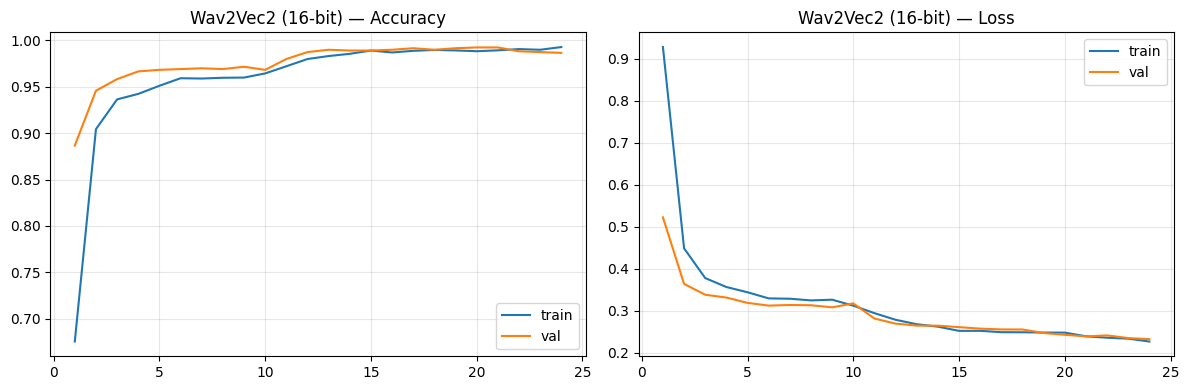

In [15]:
# ============================================================
# [16-bit] 7. Training curves
# ============================================================
hist_df_16 = plot_history(history_16, "Wav2Vec2 (16-bit)")


Wav2Vec2 (16-bit) — Test Set Performance
Accuracy   : 0.9892
Precision  : 0.9892
Recall     : 0.9892
F1 (macro) : 0.9892
ROC-AUC    : 0.9998
EER        : 0.0053

              precision    recall  f1-score   support

     Command     0.9900    0.9900    0.9900       300
Conversation     0.9868    0.9967    0.9917       300
     Numeric     0.9966    0.9900    0.9933       300
        Read     0.9833    0.9800    0.9816       300

    accuracy                         0.9892      1200
   macro avg     0.9892    0.9892    0.9892      1200
weighted avg     0.9892    0.9892    0.9892      1200



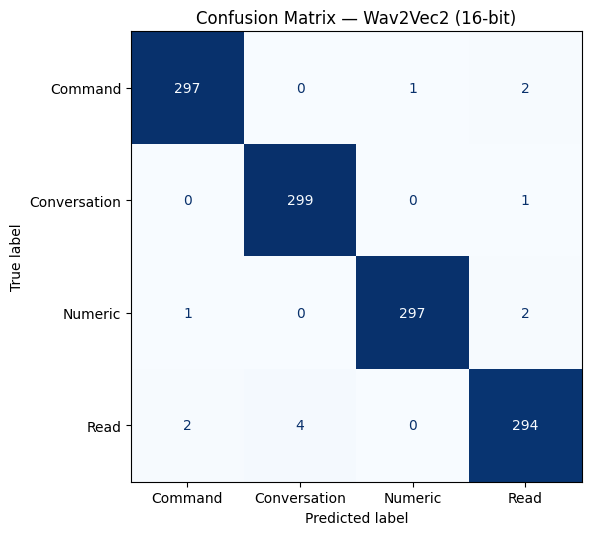

In [16]:
# ============================================================
# [16-bit] 8. Test evaluation (full report)
# ============================================================
report_16bit = full_test_report(model_16bit, test_loader_16, tag="Wav2Vec2 (16-bit)")


In [17]:
# ============================================================
# [16-bit] 9. MFCC baseline (context for the deep model's gain)
# ============================================================
baseline_16bit = run_mfcc_baseline(X_train_16, y_train_16, X_val_16, y_val_16, X_test_16, y_test_16, tag="16-bit")


[16-bit] MFCC + LogisticRegression baseline — Test Acc: 0.9042 | Macro-F1: 0.9039


In [18]:
# ============================================================
# [16-bit] 10. Free GPU memory before moving to the 1-bit run
# ============================================================
del optimizer_16bit, scheduler_16bit
gc.collect()
torch.cuda.empty_cache()
print("16-bit section complete. Model + best checkpoint retained as `model_16bit` / "
      "'best_wav2vec2_16bit.pth'.")


16-bit section complete. Model + best checkpoint retained as `model_16bit` / 'best_wav2vec2_16bit.pth'.


---
# PART B — 1-bit condition
---

In [19]:
# ============================================================
# [1-bit] 1. Load data + sanity checks
# ============================================================
X_train_1, y_train_1 = load_split(DATA1_DIR, "X_1bit_train.npy", "y_1bit_train.npy")
X_val_1, y_val_1 = load_split(DATA1_DIR, "X_1bit_val.npy", "y_1bit_val.npy")
X_test_1, y_test_1 = load_split(DATA1_DIR, "X_1bit_test.npy", "y_1bit_test.npy")
X_train_1 = np.squeeze(X_train_1)[..., np.newaxis]
X_val_1   = np.squeeze(X_val_1)[..., np.newaxis]
X_test_1  = np.squeeze(X_test_1)[..., np.newaxis]

describe_dataset("1-bit", X_train_1, y_train_1, X_val_1, y_val_1, X_test_1, y_test_1)
check_leakage(X_train_1, X_val_1, X_test_1)


Dataset: 1-bit
Train: (9600, 16000, 1) (9600,)
Val  : (1200, 16000, 1) (1200,)
Test : (1200, 16000, 1) (1200,)
dtype: float32 | min: -1.0 | max: 1.0
train class distribution: {'Command': 2400, 'Conversation': 2400, 'Numeric': 2400, 'Read': 2400}
val class distribution: {'Command': 300, 'Conversation': 300, 'Numeric': 300, 'Read': 300}
test class distribution: {'Command': 300, 'Conversation': 300, 'Numeric': 300, 'Read': 300}
Duplicate waveforms train∩val : 0
Duplicate waveforms train∩test: 1
Duplicate waveforms val∩test  : 0


(set(), {-2068957745691335127}, set())

In [20]:
# ============================================================
# [1-bit] 2. DataLoaders
# ============================================================
train_loader_1, val_loader_1, test_loader_1 = make_loaders(
    X_train_1, y_train_1, X_val_1, y_val_1, X_test_1, y_test_1
)

waveforms, labels = next(iter(train_loader_1))
print("Waveforms:", waveforms.shape, waveforms.dtype)
print("Labels   :", labels.shape, labels.dtype)


Waveforms: torch.Size([8, 16000]) torch.float32
Labels   : torch.Size([8]) torch.int64


In [21]:
# ============================================================
# [1-bit] 3. Model
# ============================================================
seed_everything(SEED)
model_1bit = Wav2Vec2Classifier(PRETRAINED_CKPT, NUM_CLASSES).to(device)
criterion_1bit = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

best_val_acc_1 = 0.0
best_state_1 = None
history_1 = []
global_epoch_1 = 0


Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [22]:
# ============================================================
# [1-bit] 4. Stage 1 — classifier head only
# ============================================================
stage = 1
n_unfrozen, max_epochs, lr, patience = STAGES[stage - 1]

model_1bit.unfreeze_top_layers(n_unfrozen)
trainable, total = model_1bit.trainable_param_summary()
print(f"[1-bit] Stage {stage}: unfreeze last {n_unfrozen} layers | trainable {trainable:,} / {total:,}")

optimizer_1bit = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_1bit.parameters()), lr=lr, weight_decay=WEIGHT_DECAY
)
n_steps = max_epochs * len(train_loader_1)
scheduler_1bit = get_cosine_schedule_with_warmup(
    optimizer_1bit, num_warmup_steps=int(WARMUP_RATIO * n_steps), num_training_steps=n_steps
)

patience_counter = 0
for epoch in range(max_epochs):
    tr_loss, tr_acc = train_one_epoch(model_1bit, train_loader_1, optimizer_1bit, criterion_1bit, scheduler_1bit)
    va_loss, va_acc = evaluate(model_1bit, val_loader_1, criterion_1bit)
    global_epoch_1 += 1

    print(f"[1-bit] Stage {stage} Epoch {epoch+1}/{max_epochs} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {va_loss:.4f} Acc {va_acc:.4f}")
    history_1.append({"global_epoch": global_epoch_1, "stage": stage,
                       "train_loss": tr_loss, "train_acc": tr_acc, "val_loss": va_loss, "val_acc": va_acc})

    if va_acc > best_val_acc_1:
        best_val_acc_1 = va_acc
        best_state_1 = copy.deepcopy(model_1bit.state_dict())
        torch.save(best_state_1, os.path.join(OUT_DIR, "best_wav2vec2_1bit.pth"))
        patience_counter = 0
        print(f"  -> new best (Val Acc = {best_val_acc_1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("  -> early stopping stage", stage)
            break

print(f"\n[1-bit] Stage 1 finished. Best Val Acc so far: {best_val_acc_1:.4f}")


[1-bit] Stage 1: unfreeze last 0 layers | trainable 1,184,274 / 95,555,986
[1-bit] Stage 1 Epoch 1/8 | Train Loss 1.0272 Acc 0.6035 | Val Loss 0.8160 Acc 0.6975
  -> new best (Val Acc = 0.6975)
[1-bit] Stage 1 Epoch 2/8 | Train Loss 0.7332 Acc 0.7333 | Val Loss 0.7569 Acc 0.7317
  -> new best (Val Acc = 0.7317)
[1-bit] Stage 1 Epoch 3/8 | Train Loss 0.6964 Acc 0.7512 | Val Loss 0.7278 Acc 0.7433
  -> new best (Val Acc = 0.7433)
[1-bit] Stage 1 Epoch 4/8 | Train Loss 0.6732 Acc 0.7664 | Val Loss 0.7225 Acc 0.7442
  -> new best (Val Acc = 0.7442)
[1-bit] Stage 1 Epoch 5/8 | Train Loss 0.6640 Acc 0.7721 | Val Loss 0.7012 Acc 0.7600
  -> new best (Val Acc = 0.7600)
[1-bit] Stage 1 Epoch 6/8 | Train Loss 0.6530 Acc 0.7816 | Val Loss 0.7036 Acc 0.7583
[1-bit] Stage 1 Epoch 7/8 | Train Loss 0.6390 Acc 0.7933 | Val Loss 0.7030 Acc 0.7592
[1-bit] Stage 1 Epoch 8/8 | Train Loss 0.6308 Acc 0.7897 | Val Loss 0.6985 Acc 0.7558
  -> early stopping stage 1

[1-bit] Stage 1 finished. Best Val Acc so f

In [23]:
# ============================================================
# [1-bit] 5. Stage 2 — unfreeze last 4 transformer layers
# ============================================================
stage = 2
n_unfrozen, max_epochs, lr, patience = STAGES[stage - 1]

model_1bit.load_state_dict(best_state_1)
model_1bit.unfreeze_top_layers(n_unfrozen)
trainable, total = model_1bit.trainable_param_summary()
print(f"[1-bit] Stage {stage}: unfreeze last {n_unfrozen} layers | trainable {trainable:,} / {total:,}")

optimizer_1bit = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_1bit.parameters()), lr=lr, weight_decay=WEIGHT_DECAY
)
n_steps = max_epochs * len(train_loader_1)
scheduler_1bit = get_cosine_schedule_with_warmup(
    optimizer_1bit, num_warmup_steps=int(WARMUP_RATIO * n_steps), num_training_steps=n_steps
)

patience_counter = 0
for epoch in range(max_epochs):
    tr_loss, tr_acc = train_one_epoch(model_1bit, train_loader_1, optimizer_1bit, criterion_1bit, scheduler_1bit)
    va_loss, va_acc = evaluate(model_1bit, val_loader_1, criterion_1bit)
    global_epoch_1 += 1

    print(f"[1-bit] Stage {stage} Epoch {epoch+1}/{max_epochs} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {va_loss:.4f} Acc {va_acc:.4f}")
    history_1.append({"global_epoch": global_epoch_1, "stage": stage,
                       "train_loss": tr_loss, "train_acc": tr_acc, "val_loss": va_loss, "val_acc": va_acc})

    if va_acc > best_val_acc_1:
        best_val_acc_1 = va_acc
        best_state_1 = copy.deepcopy(model_1bit.state_dict())
        torch.save(best_state_1, os.path.join(OUT_DIR, "best_wav2vec2_1bit.pth"))
        patience_counter = 0
        print(f"  -> new best (Val Acc = {best_val_acc_1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("  -> early stopping stage", stage)
            break

print(f"\n[1-bit] Stage 2 finished. Best Val Acc so far: {best_val_acc_1:.4f}")


[1-bit] Stage 2: unfreeze last 4 layers | trainable 29,535,762 / 95,555,986
[1-bit] Stage 2 Epoch 1/10 | Train Loss 0.6501 Acc 0.7843 | Val Loss 0.7663 Acc 0.7067
[1-bit] Stage 2 Epoch 2/10 | Train Loss 0.6232 Acc 0.7957 | Val Loss 0.7645 Acc 0.7117
[1-bit] Stage 2 Epoch 3/10 | Train Loss 0.5982 Acc 0.8141 | Val Loss 0.6688 Acc 0.7842
  -> new best (Val Acc = 0.7842)
[1-bit] Stage 2 Epoch 4/10 | Train Loss 0.5747 Acc 0.8237 | Val Loss 0.6517 Acc 0.7850
  -> new best (Val Acc = 0.7850)
[1-bit] Stage 2 Epoch 5/10 | Train Loss 0.5588 Acc 0.8292 | Val Loss 0.6285 Acc 0.8117
  -> new best (Val Acc = 0.8117)
[1-bit] Stage 2 Epoch 6/10 | Train Loss 0.5505 Acc 0.8378 | Val Loss 0.6536 Acc 0.8025
[1-bit] Stage 2 Epoch 7/10 | Train Loss 0.5258 Acc 0.8498 | Val Loss 0.6580 Acc 0.7908
[1-bit] Stage 2 Epoch 8/10 | Train Loss 0.5209 Acc 0.8533 | Val Loss 0.6107 Acc 0.8167
  -> new best (Val Acc = 0.8167)
[1-bit] Stage 2 Epoch 9/10 | Train Loss 0.5262 Acc 0.8527 | Val Loss 0.6139 Acc 0.8108
[1-bit] S

In [24]:
# ============================================================
# [1-bit] 6. Stage 3 — unfreeze last 8 transformer layers
# ============================================================
stage = 3
n_unfrozen, max_epochs, lr, patience = STAGES[stage - 1]

model_1bit.load_state_dict(best_state_1)
model_1bit.unfreeze_top_layers(n_unfrozen)
trainable, total = model_1bit.trainable_param_summary()
print(f"[1-bit] Stage {stage}: unfreeze last {n_unfrozen} layers | trainable {trainable:,} / {total:,}")

optimizer_1bit = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_1bit.parameters()), lr=lr, weight_decay=WEIGHT_DECAY
)
n_steps = max_epochs * len(train_loader_1)
scheduler_1bit = get_cosine_schedule_with_warmup(
    optimizer_1bit, num_warmup_steps=int(WARMUP_RATIO * n_steps), num_training_steps=n_steps
)

patience_counter = 0
for epoch in range(max_epochs):
    tr_loss, tr_acc = train_one_epoch(model_1bit, train_loader_1, optimizer_1bit, criterion_1bit, scheduler_1bit)
    va_loss, va_acc = evaluate(model_1bit, val_loader_1, criterion_1bit)
    global_epoch_1 += 1

    print(f"[1-bit] Stage {stage} Epoch {epoch+1}/{max_epochs} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {va_loss:.4f} Acc {va_acc:.4f}")
    history_1.append({"global_epoch": global_epoch_1, "stage": stage,
                       "train_loss": tr_loss, "train_acc": tr_acc, "val_loss": va_loss, "val_acc": va_acc})

    if va_acc > best_val_acc_1:
        best_val_acc_1 = va_acc
        best_state_1 = copy.deepcopy(model_1bit.state_dict())
        torch.save(best_state_1, os.path.join(OUT_DIR, "best_wav2vec2_1bit.pth"))
        patience_counter = 0
        print(f"  -> new best (Val Acc = {best_val_acc_1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("  -> early stopping stage", stage)
            break

model_1bit.load_state_dict(best_state_1)
print(f"\n[1-bit] All stages finished. Best Validation Accuracy: {best_val_acc_1:.4f}")


[1-bit] Stage 3: unfreeze last 8 layers | trainable 57,887,250 / 95,555,986
[1-bit] Stage 3 Epoch 1/8 | Train Loss 0.5238 Acc 0.8504 | Val Loss 0.5703 Acc 0.8342
  -> new best (Val Acc = 0.8342)
[1-bit] Stage 3 Epoch 2/8 | Train Loss 0.5107 Acc 0.8605 | Val Loss 0.5255 Acc 0.8583
  -> new best (Val Acc = 0.8583)
[1-bit] Stage 3 Epoch 3/8 | Train Loss 0.4955 Acc 0.8664 | Val Loss 0.5055 Acc 0.8500
[1-bit] Stage 3 Epoch 4/8 | Train Loss 0.4926 Acc 0.8728 | Val Loss 0.5602 Acc 0.8225
[1-bit] Stage 3 Epoch 5/8 | Train Loss 0.4732 Acc 0.8774 | Val Loss 0.4618 Acc 0.8858
  -> new best (Val Acc = 0.8858)
[1-bit] Stage 3 Epoch 6/8 | Train Loss 0.4515 Acc 0.8855 | Val Loss 0.4823 Acc 0.8700
[1-bit] Stage 3 Epoch 7/8 | Train Loss 0.4565 Acc 0.8879 | Val Loss 0.4832 Acc 0.8700
[1-bit] Stage 3 Epoch 8/8 | Train Loss 0.4432 Acc 0.8926 | Val Loss 0.4810 Acc 0.8683

[1-bit] All stages finished. Best Validation Accuracy: 0.8858


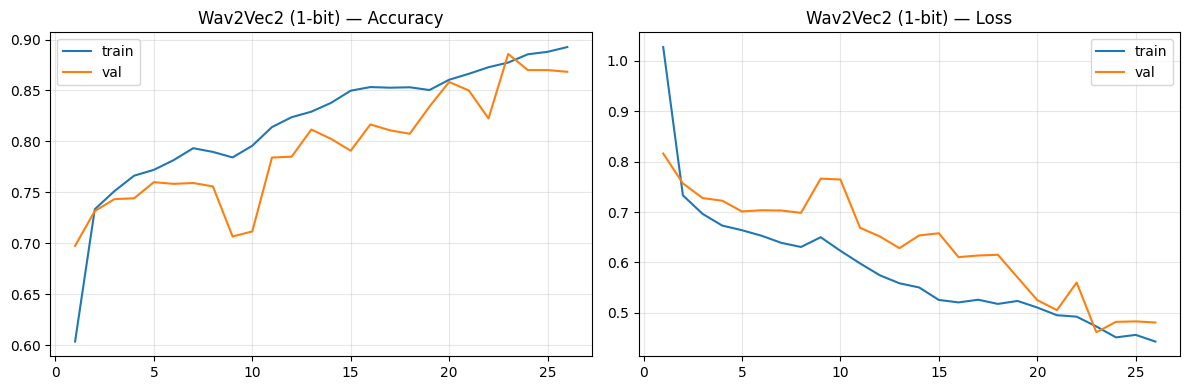

In [25]:
# ============================================================
# [1-bit] 7. Training curves
# ============================================================
hist_df_1 = plot_history(history_1, "Wav2Vec2 (1-bit)")


Wav2Vec2 (1-bit) — Test Set Performance
Accuracy   : 0.8908
Precision  : 0.8923
Recall     : 0.8908
F1 (macro) : 0.8900
ROC-AUC    : 0.9808
EER        : 0.0583

              precision    recall  f1-score   support

     Command     0.8299    0.9433    0.8830       300
Conversation     0.8938    0.8700    0.8818       300
     Numeric     0.9799    0.9767    0.9783       300
        Read     0.8657    0.7733    0.8169       300

    accuracy                         0.8908      1200
   macro avg     0.8923    0.8908    0.8900      1200
weighted avg     0.8923    0.8908    0.8900      1200



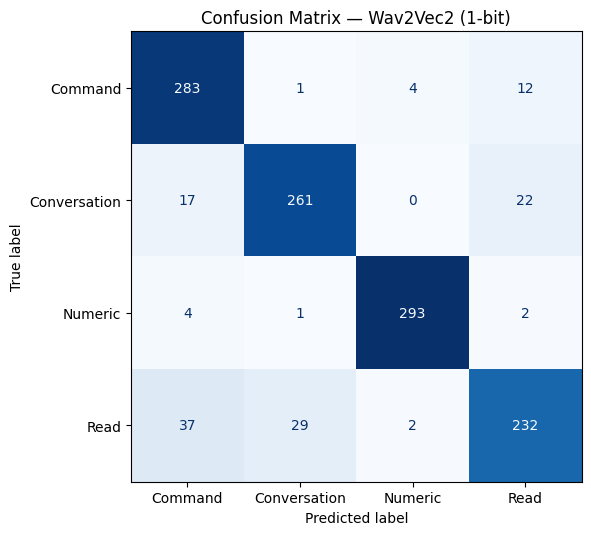

In [26]:
# ============================================================
# [1-bit] 8. Test evaluation (full report)
# ============================================================
report_1bit = full_test_report(model_1bit, test_loader_1, tag="Wav2Vec2 (1-bit)")


In [27]:
# ============================================================
# [1-bit] 9. MFCC baseline
# ============================================================
baseline_1bit = run_mfcc_baseline(X_train_1, y_train_1, X_val_1, y_val_1, X_test_1, y_test_1, tag="1-bit")


[1-bit] MFCC + LogisticRegression baseline — Test Acc: 0.8258 | Macro-F1: 0.8252


---
# Final comparison — 16-bit vs 1-bit
---

In [28]:
# ============================================================
# Comparison — bootstrap CI + McNemar test + results table
# ============================================================
def bootstrap_ci_paired(labels, preds, metric_fn, n_boot=2000, seed=0):
    rng = np.random.RandomState(seed)
    n = len(labels)
    stats = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        stats.append(metric_fn(labels[idx], preds[idx]))
    lo, hi = np.percentile(stats, [2.5, 97.5])
    return float(np.mean(stats)), float(lo), float(hi)


def mcnemar_test(labels, preds_a, preds_b):
    correct_a = (preds_a == labels)
    correct_b = (preds_b == labels)
    n01 = int(np.sum(correct_a & ~correct_b))
    n10 = int(np.sum(~correct_a & correct_b))
    if n01 + n10 == 0:
        return 1.0
    stat = (abs(n01 - n10) - 1) ** 2 / (n01 + n10)
    return 1 - chi2.cdf(stat, df=1)


acc_ci_16 = bootstrap_ci_paired(report_16bit["labels"], report_16bit["preds"], accuracy_score)
acc_ci_1 = bootstrap_ci_paired(report_1bit["labels"], report_1bit["preds"], accuracy_score)

print(f"16-bit test accuracy 95% bootstrap CI: mean={acc_ci_16[0]:.4f} [{acc_ci_16[1]:.4f}, {acc_ci_16[2]:.4f}]")
print(f"1-bit  test accuracy 95% bootstrap CI: mean={acc_ci_1[0]:.4f} [{acc_ci_1[1]:.4f}, {acc_ci_1[2]:.4f}]")

if len(report_16bit["labels"]) == len(report_1bit["labels"]):
    p_val = mcnemar_test(report_16bit["labels"], report_16bit["preds"], report_1bit["preds"])
    print(f"McNemar test (16-bit vs 1-bit predictions), p-value = {p_val:.4g}")
else:
    print("Test sets differ in size/order — McNemar test needs matched items, skipping.")

final_table = pd.DataFrame([
    {"Model": "MFCC + LogisticRegression", "Condition": "16-bit",
     "Accuracy": baseline_16bit["accuracy"], "Macro-F1": baseline_16bit["macro_f1"]},
    {"Model": "MFCC + LogisticRegression", "Condition": "1-bit",
     "Accuracy": baseline_1bit["accuracy"], "Macro-F1": baseline_1bit["macro_f1"]},
    {"Model": "Wav2Vec2 (this run)", "Condition": "16-bit",
     "Accuracy": report_16bit["accuracy"], "Macro-F1": report_16bit["f1_macro"]},
    {"Model": "Wav2Vec2 (this run)", "Condition": "1-bit",
     "Accuracy": report_1bit["accuracy"], "Macro-F1": report_1bit["f1_macro"]},
])
print(final_table.to_string(index=False))

final_table.to_csv(os.path.join(OUT_DIR, "final_results_table.csv"), index=False)
hist_df_16.to_csv(os.path.join(OUT_DIR, "history_16bit.csv"), index=False)
hist_df_1.to_csv(os.path.join(OUT_DIR, "history_1bit.csv"), index=False)
print(f"\nArtifacts written to: {OUT_DIR}")


16-bit test accuracy 95% bootstrap CI: mean=0.9892 [0.9833, 0.9942]
1-bit  test accuracy 95% bootstrap CI: mean=0.8906 [0.8725, 0.9075]
McNemar test (16-bit vs 1-bit predictions), p-value = 0
                    Model Condition  Accuracy  Macro-F1
MFCC + LogisticRegression    16-bit  0.904167  0.903917
MFCC + LogisticRegression     1-bit  0.825833  0.825150
      Wav2Vec2 (this run)    16-bit  0.989167  0.989164
      Wav2Vec2 (this run)     1-bit  0.890833  0.889988

Artifacts written to: /kaggle/working/results


# Cross Inference

Wav2Vec2 (train=16-bit, test=1-bit) — Test Set Performance
Accuracy   : 0.3983
Precision  : 0.6763
Recall     : 0.3983
F1 (macro) : 0.3308
ROC-AUC    : 0.7349
EER        : 0.3117

              precision    recall  f1-score   support

     Command     0.2989    0.9467    0.4544       300
Conversation     1.0000    0.0033    0.0066       300
     Numeric     0.9000    0.5100    0.6511       300
        Read     0.5063    0.1333    0.2111       300

    accuracy                         0.3983      1200
   macro avg     0.6763    0.3983    0.3308      1200
weighted avg     0.6763    0.3983    0.3308      1200



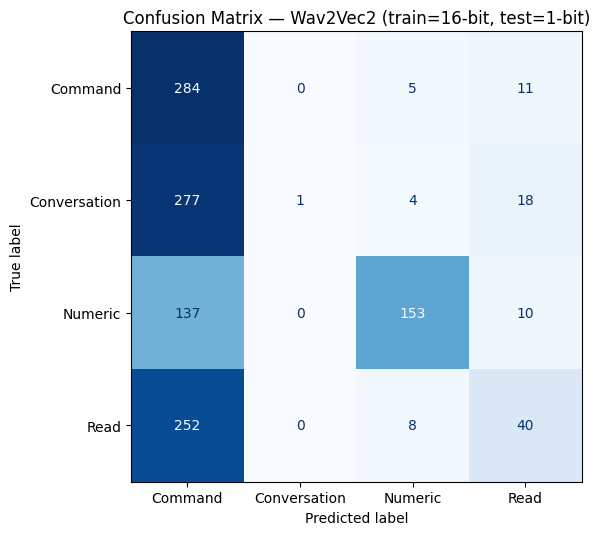

Wav2Vec2 (train=1-bit, test=16-bit) — Test Set Performance
Accuracy   : 0.4108
Precision  : 0.5276
Recall     : 0.4108
F1 (macro) : 0.3701
ROC-AUC    : 0.8555
EER        : 0.2256

              precision    recall  f1-score   support

     Command     0.6050    0.2400    0.3437       300
Conversation     0.5870    0.3600    0.4463       300
     Numeric     0.5873    0.1233    0.2039       300
        Read     0.3309    0.9200    0.4868       300

    accuracy                         0.4108      1200
   macro avg     0.5276    0.4108    0.3701      1200
weighted avg     0.5276    0.4108    0.3701      1200



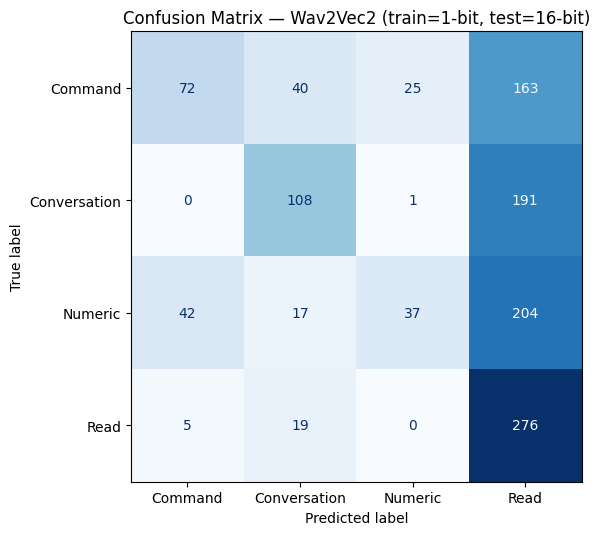


=== Cross-inference summary ===
Train 16-bit -> Test 1-bit  : acc = 0.3983
Train 1-bit  -> Test 16-bit : acc = 0.4108
(for reference) Train 16-bit -> Test 16-bit : acc = 0.9892
(for reference) Train 1-bit  -> Test 1-bit   : acc = 0.8908


In [32]:
# ============================================================
# Cross-inference (add as a new cell after both PART A and PART B have run)
# ============================================================

# A. Train on 16-bit, test on 1-bit
report_16train_1test = full_test_report(
    model_16bit, test_loader_1, tag="Wav2Vec2 (train=16-bit, test=1-bit)"
)

# B. Train on 1-bit, test on 16-bit
report_1train_16test = full_test_report(
    model_1bit, test_loader_16, tag="Wav2Vec2 (train=1-bit, test=16-bit)"
)

# Optional: quick side-by-side summary
print("\n=== Cross-inference summary ===")
print(f"Train 16-bit -> Test 1-bit  : acc = {report_16train_1test['accuracy']:.4f}")
print(f"Train 1-bit  -> Test 16-bit : acc = {report_1train_16test['accuracy']:.4f}")
print(f"(for reference) Train 16-bit -> Test 16-bit : acc = {report_16bit['accuracy']:.4f}")
print(f"(for reference) Train 1-bit  -> Test 1-bit   : acc = {report_1bit['accuracy']:.4f}")

# Noise Robustness Check

16-bit model @ 15dB SNR — Test Set Performance
Accuracy   : 0.6408
Precision  : 0.7931
Recall     : 0.6408
F1 (macro) : 0.5889
ROC-AUC    : 0.9772
EER        : 0.0719

              precision    recall  f1-score   support

     Command     0.6548    0.9800    0.7850       300
Conversation     1.0000    0.4200    0.5915       300
     Numeric     1.0000    0.1767    0.3003       300
        Read     0.5175    0.9867    0.6789       300

    accuracy                         0.6408      1200
   macro avg     0.7931    0.6408    0.5889      1200
weighted avg     0.7931    0.6408    0.5889      1200



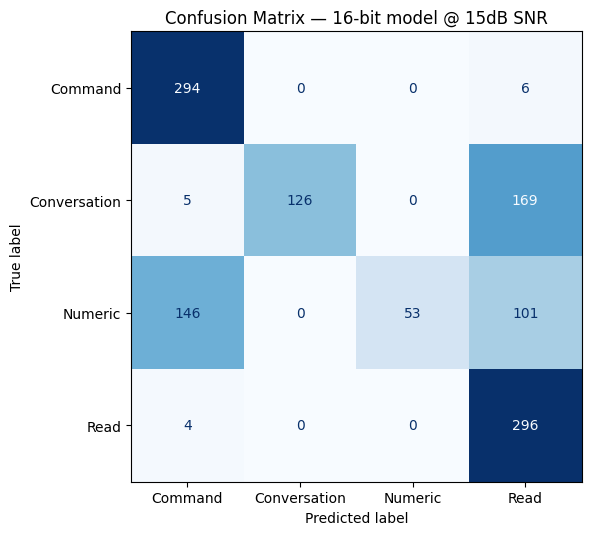

1-bit model @ 15dB SNR — Test Set Performance
Accuracy   : 0.5683
Precision  : 0.4913
Recall     : 0.5683
F1 (macro) : 0.4864
ROC-AUC    : 0.9296
EER        : 0.1442

              precision    recall  f1-score   support

     Command     0.5811    0.9200    0.7123       300
Conversation     0.9226    0.4767    0.6286       300
     Numeric     0.0000    0.0000    0.0000       300
        Read     0.4614    0.8767    0.6046       300

    accuracy                         0.5683      1200
   macro avg     0.4913    0.5683    0.4864      1200
weighted avg     0.4913    0.5683    0.4864      1200



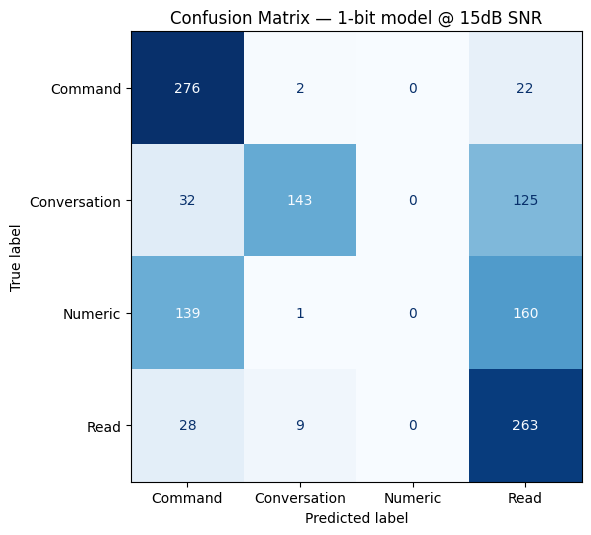

16-bit model @ 10dB SNR — Test Set Performance
Accuracy   : 0.5108
Precision  : 0.7647
Recall     : 0.5108
F1 (macro) : 0.3859
ROC-AUC    : 0.9371
EER        : 0.1325

              precision    recall  f1-score   support

     Command     0.6568    0.9633    0.7811       300
Conversation     1.0000    0.0833    0.1538       300
     Numeric     1.0000    0.0200    0.0392       300
        Read     0.4019    0.9767    0.5695       300

    accuracy                         0.5108      1200
   macro avg     0.7647    0.5108    0.3859      1200
weighted avg     0.7647    0.5108    0.3859      1200



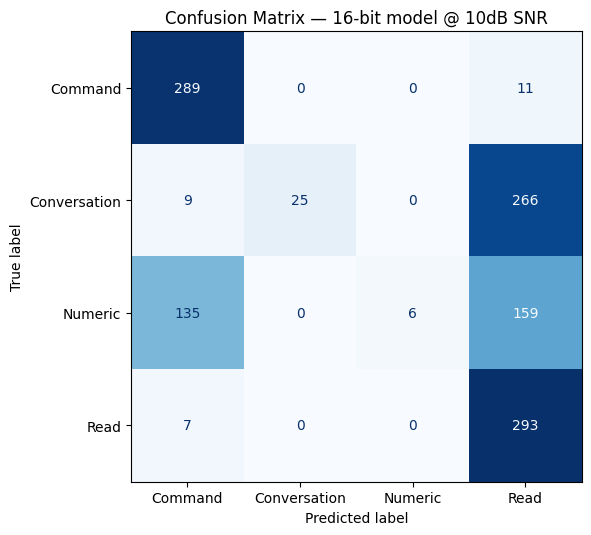

1-bit model @ 10dB SNR — Test Set Performance
Accuracy   : 0.4892
Precision  : 0.4678
Recall     : 0.4892
F1 (macro) : 0.4071
ROC-AUC    : 0.8622
EER        : 0.2167

              precision    recall  f1-score   support

     Command     0.3912    0.9533    0.5548       300
Conversation     0.9053    0.2867    0.4354       300
     Numeric     0.0000    0.0000    0.0000       300
        Read     0.5749    0.7167    0.6380       300

    accuracy                         0.4892      1200
   macro avg     0.4678    0.4892    0.4071      1200
weighted avg     0.4678    0.4892    0.4071      1200



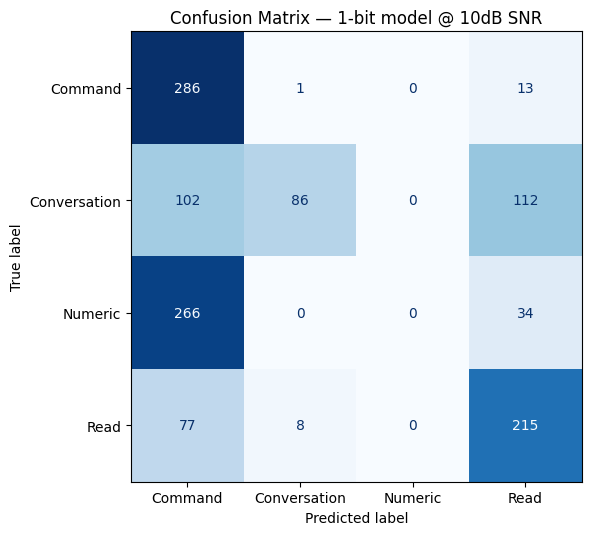

16-bit model @ 5dB SNR — Test Set Performance
Accuracy   : 0.4692
Precision  : 0.2499
Recall     : 0.4692
F1 (macro) : 0.3214
ROC-AUC    : 0.8712
EER        : 0.2092

              precision    recall  f1-score   support

     Command     0.6214    0.9300    0.7450       300
Conversation     0.0000    0.0000    0.0000       300
     Numeric     0.0000    0.0000    0.0000       300
        Read     0.3782    0.9467    0.5404       300

    accuracy                         0.4692      1200
   macro avg     0.2499    0.4692    0.3214      1200
weighted avg     0.2499    0.4692    0.3214      1200



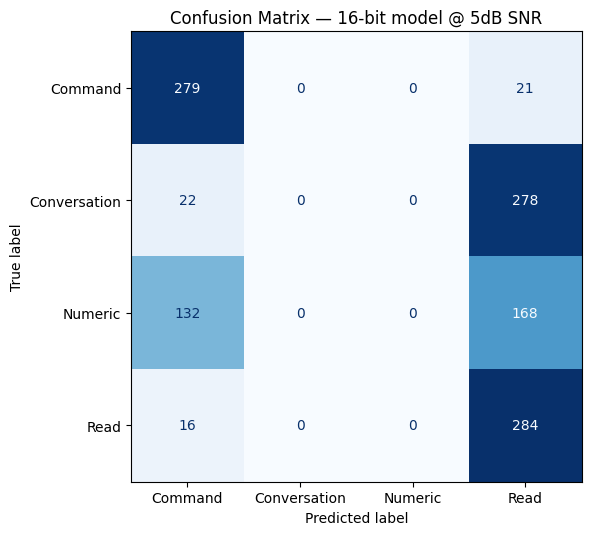

1-bit model @ 5dB SNR — Test Set Performance
Accuracy   : 0.3675
Precision  : 0.4575
Recall     : 0.3675
F1 (macro) : 0.2758
ROC-AUC    : 0.6841
EER        : 0.3578

              precision    recall  f1-score   support

     Command     0.3012    0.9700    0.4597       300
Conversation     0.9231    0.0800    0.1472       300
     Numeric     0.0000    0.0000    0.0000       300
        Read     0.6058    0.4200    0.4961       300

    accuracy                         0.3675      1200
   macro avg     0.4575    0.3675    0.2758      1200
weighted avg     0.4575    0.3675    0.2758      1200



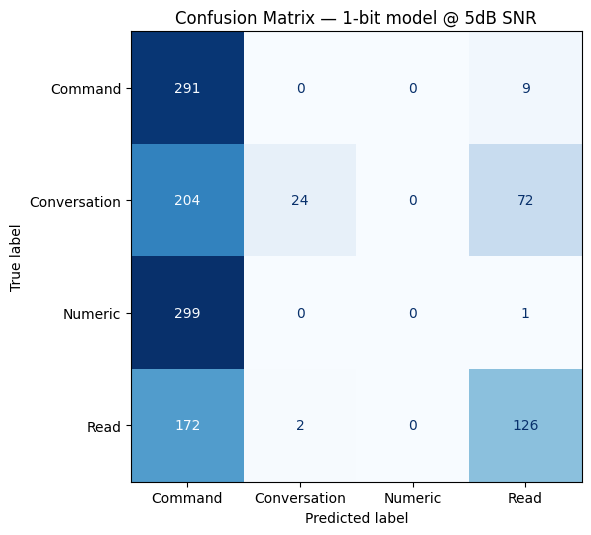


=== Noise robustness summary (accuracy) ===
Condition Clean     15dB      10dB      5dB       
16-bit    0.9892    0.6408    0.5108    0.4692    
1-bit     0.8908    0.5683    0.4892    0.3675    


In [33]:
# ============================================================
# Noise robustness check — add white noise at 5dB / 10dB / 15dB SNR
# ============================================================

def add_noise_at_snr(X, snr_db, seed=0):
    """X: (N, T[, 1]) waveform array. Adds white Gaussian noise at target SNR (dB)."""
    rng = np.random.RandomState(seed)
    X = X.astype(np.float32).copy()
    orig_shape = X.shape
    X_flat = X.reshape(orig_shape[0], -1)

    noisy = np.empty_like(X_flat)
    for i in range(X_flat.shape[0]):
        sig = X_flat[i]
        sig_power = np.mean(sig ** 2) + 1e-12
        snr_linear = 10 ** (snr_db / 10)
        noise_power = sig_power / snr_linear
        noise = rng.normal(0, np.sqrt(noise_power), size=sig.shape).astype(np.float32)
        noisy[i] = sig + noise

    return noisy.reshape(orig_shape)


def make_test_loader_from_array(X, y):
    class _NoisyDS(Dataset):
        def __init__(self, X, y):
            self.X = X.astype(np.float32)
            self.y = y
        def __len__(self):
            return len(self.y)
        def __getitem__(self, idx):
            wav = self.X[idx].squeeze()
            return torch.tensor(wav, dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)

    return DataLoader(_NoisyDS(X, y), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


noise_results = {}

for snr_db in [15, 10, 5]:
    # --- 16-bit model, tested on noisy 16-bit test set ---
    X_test_16_noisy = add_noise_at_snr(X_test_16, snr_db, seed=0)
    loader_16_noisy = make_test_loader_from_array(X_test_16_noisy, y_test_16)
    r16 = full_test_report(model_16bit, loader_16_noisy, tag=f"16-bit model @ {snr_db}dB SNR")
    noise_results[("16bit", snr_db)] = r16["accuracy"]

    # --- 1-bit model, tested on noisy 1-bit test set ---
    X_test_1_noisy = add_noise_at_snr(X_test_1, snr_db, seed=0)
    loader_1_noisy = make_test_loader_from_array(X_test_1_noisy, y_test_1)
    r1 = full_test_report(model_1bit, loader_1_noisy, tag=f"1-bit model @ {snr_db}dB SNR")
    noise_results[("1bit", snr_db)] = r1["accuracy"]

# --- Summary table ---
print("\n=== Noise robustness summary (accuracy) ===")
print(f"{'Condition':<10}{'Clean':<10}{'15dB':<10}{'10dB':<10}{'5dB':<10}")
print(f"{'16-bit':<10}{report_16bit['accuracy']:<10.4f}"
      f"{noise_results[('16bit',15)]:<10.4f}{noise_results[('16bit',10)]:<10.4f}{noise_results[('16bit',5)]:<10.4f}")
print(f"{'1-bit':<10}{report_1bit['accuracy']:<10.4f}"
      f"{noise_results[('1bit',15)]:<10.4f}{noise_results[('1bit',10)]:<10.4f}{noise_results[('1bit',5)]:<10.4f}")

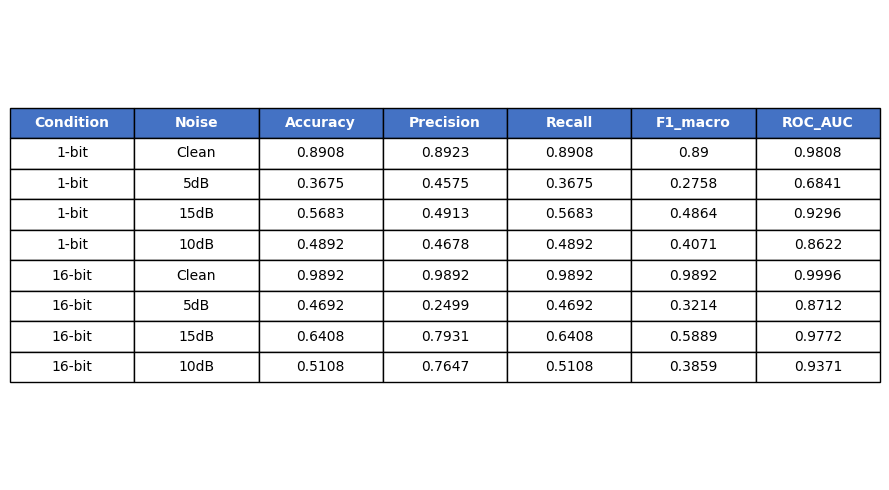

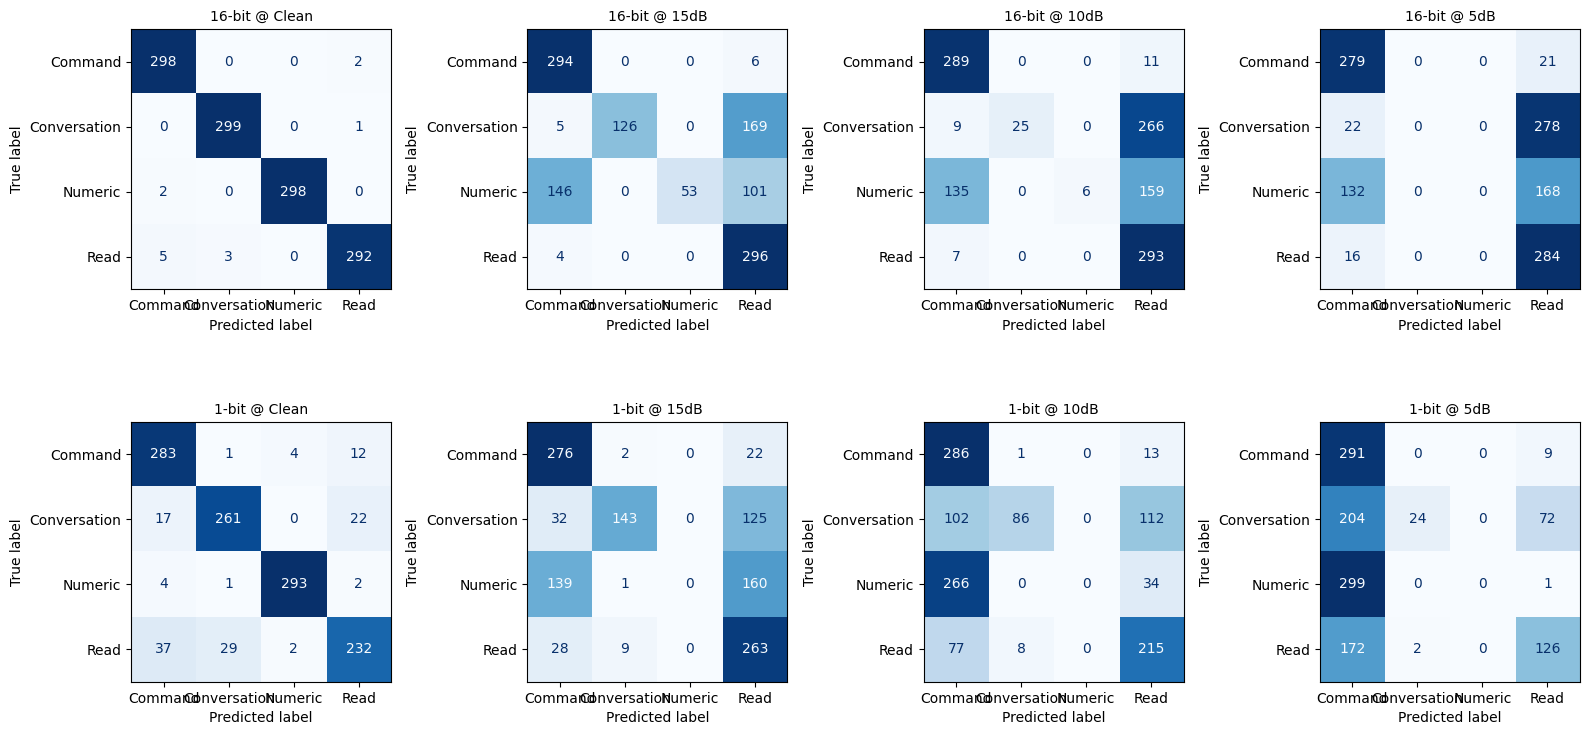


All saved to: /kaggle/working/noise_robustness_report
['cm_1bit_10db.png', 'cm_1bit_clean.png', 'cm_1bit_5db.png', 'noise_robustness_summary.csv', 'cm_16bit_15db.png', 'cm_16bit_10db.png', 'cm_16bit_clean.png', 'all_confusion_matrices_grid.png', 'cm_1bit_15db.png', 'cm_16bit_5db.png', 'summary_table.png']


In [35]:
# ============================================================
# Noise robustness — full report generation (save-ready)
# ============================================================
import os

OUT_DIR = "/kaggle/working/noise_robustness_report"
os.makedirs(OUT_DIR, exist_ok=True)

def full_test_report_saveable(model, test_loader, tag: str, save_path=None):
    """Same as full_test_report, but saves the confusion matrix figure instead of
    just showing it, and returns everything needed for the summary table."""
    criterion = nn.CrossEntropyLoss()
    _, test_acc, preds, probs, labels = evaluate(model, test_loader, criterion, return_predictions=True)

    precision = precision_score(labels, preds, average="macro", zero_division=0)
    recall = recall_score(labels, preds, average="macro", zero_division=0)
    f1 = f1_score(labels, preds, average="macro", zero_division=0)

    labels_bin = label_binarize(labels, classes=list(range(NUM_CLASSES)))
    try:
        roc_auc = roc_auc_score(labels_bin, probs, average="macro", multi_class="ovr")
    except ValueError:
        roc_auc = float("nan")

    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(5, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d"
    )
    ax.set_title(tag, fontsize=11)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close(fig)

    return {"tag": tag, "accuracy": test_acc, "precision": precision, "recall": recall,
            "f1_macro": f1, "roc_auc": roc_auc, "preds": preds, "probs": probs,
            "labels": labels, "cm": cm}


# ---- Run all conditions and collect results ----
rows = []
cm_data = []  # (tag, cm) for the combined grid later
def run_and_log(model, X, y, condition_label, snr_value, fname):
    """snr_value: None for clean, or a number (5, 10, 15) for noisy."""
    if snr_value is None:
        Xn = X
        display_label = "Clean"
    else:
        Xn = add_noise_at_snr(X, snr_value, seed=0)
        display_label = f"{snr_value}dB"

    loader = make_test_loader_from_array(Xn, y)
    tag = f"{condition_label} @ {display_label}"
    save_path = os.path.join(OUT_DIR, f"cm_{fname}.png")
    r = full_test_report_saveable(model, loader, tag, save_path=save_path)
    rows.append({
        "Condition": condition_label, "Noise": display_label,
        "Accuracy": r["accuracy"], "Precision": r["precision"],
        "Recall": r["recall"], "F1_macro": r["f1_macro"], "ROC_AUC": r["roc_auc"]
    })
    cm_data.append((tag, r["cm"]))


for cond, model, X, y, tagshort in [
    ("16-bit", model_16bit, X_test_16, y_test_16, "16bit"),
    ("1-bit",  model_1bit,  X_test_1,  y_test_1,  "1bit"),
]:
    run_and_log(model, X, y, cond, None, f"{tagshort}_clean")
    for snr in [15, 10, 5]:
        run_and_log(model, X, y, cond, snr, f"{tagshort}_{snr}db")

# ---- Save summary table ----
results_df = pd.DataFrame(rows)
results_df = results_df.sort_values(["Condition", "Noise"], ascending=[True, False])
results_df.to_csv(os.path.join(OUT_DIR, "noise_robustness_summary.csv"), index=False)

# Styled table image (nice for slides)
fig, ax = plt.subplots(figsize=(9, len(results_df) * 0.5 + 1))
ax.axis("off")
tbl = ax.table(
    cellText=results_df.round(4).values,
    colLabels=results_df.columns,
    cellLoc="center", loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.5)
for j in range(len(results_df.columns)):
    tbl[0, j].set_facecolor("#4472C4")
    tbl[0, j].set_text_props(color="white", weight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "summary_table.png"), dpi=200, bbox_inches="tight")
plt.show()

# ---- Combined confusion matrix grid (all 8 in one figure) ----
n = len(cm_data)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
axes = axes.flatten()
for i, (tag, cm) in enumerate(cm_data):
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(
        ax=axes[i], cmap="Blues", colorbar=False, values_format="d"
    )
    axes[i].set_title(tag, fontsize=10)
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "all_confusion_matrices_grid.png"), dpi=200, bbox_inches="tight")
plt.show()

print(f"\nAll saved to: {OUT_DIR}")
print(os.listdir(OUT_DIR))

## Reporting checklist

- [ ] This notebook runs a **single seed** per condition by default (`SEED = 42`) for
      clarity. For a publishable claim, rerun both PART A and PART B with 2–4 more
      seed values and report **mean ± std**, not one run.
- [ ] Confirm the leakage check found 0 duplicates in both conditions before trusting
      any test number.
- [ ] Report the MFCC baseline alongside wav2vec2 so the pretrained representation's
      contribution is quantified.
- [ ] If McNemar's `p > 0.05`, say the 16-bit vs 1-bit difference is not statistically
      distinguishable at this sample size rather than claiming a difference.
- [ ] If 1-bit underperforms substantially, treat that as a genuine robustness finding
      (domain mismatch between the pretrained CNN encoder and 1-bit/PDM-style audio),
      not something to tune away.
